# Model fitting 2: Only SSC, MCMC without minimizer step and ultranest backend

In [1]:
#import warnings
#warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
import jetset
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

In [2]:
print(jetset.__version__)

1.4.0rc3


In [3]:
test_SEDs

['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

## Loading data



In [4]:
print(test_SEDs[1])
data=Data.from_file(test_SEDs[1])


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



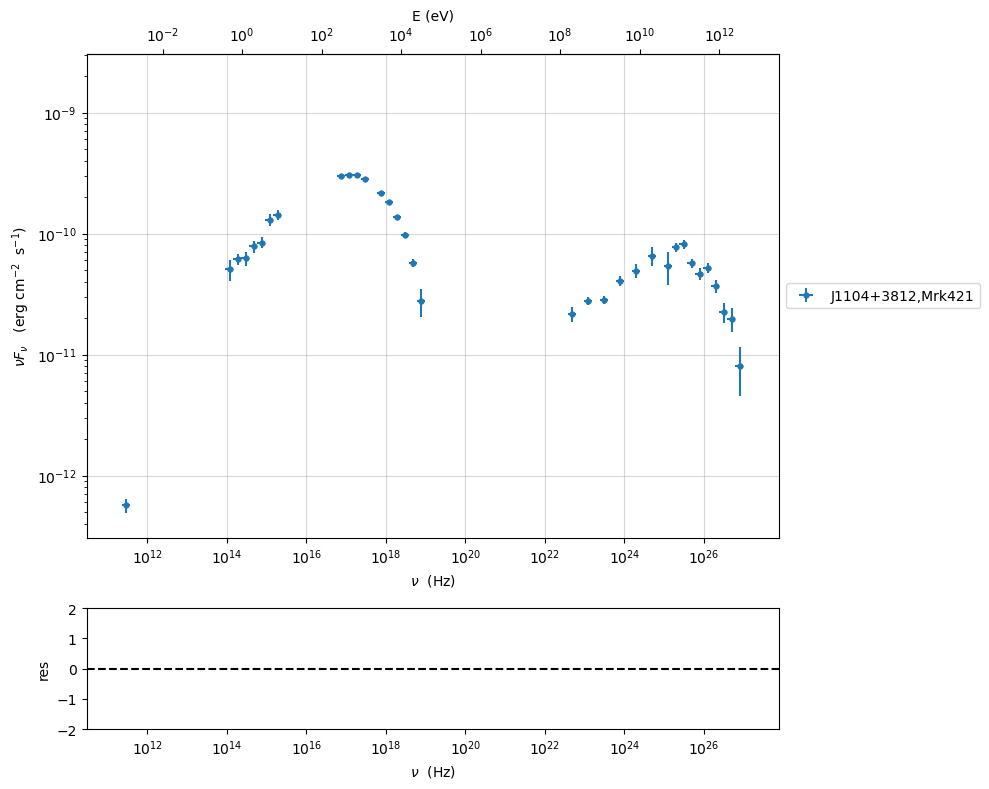

In [5]:
%matplotlib inline
sed_data=ObsData(data_table=data)
sed_data.group_data(bin_width=0.2)

sed_data.add_systematics(0.1,[10.**6,10.**16])
p=sed_data.plot_sed()
#p.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

In [6]:
sed_data.save('Mrk_401.pkl')

## creating and setting the sampler

In [7]:

from jetset.mcmc_ultranest import UltraNestSampler
from jetset.minimizer import ModelMinimizer


In [8]:
from jetset.jet_model import Jet
from jetset.model_manager import FitModel
fit_model=FitModel(jet=Jet(emitters_distribution='plc'),name='plain_plc')

/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/model_manager.py:259: UserWarning: no cosmology defined, using the one from jet FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
  warnings.warn(m)


We create a `ModelMinimizer` object directly for the MCMC step, skipping the `.run()` method, replaced by the call of the `prepare_fit` method.

In [9]:
model_minimizer = model_minimizer=ModelMinimizer('mcmc')
model_minimizer.prepare_fit(fit_model,
                            sed_data,
                            nu_fit_start=1E11,
                            nu_fit_stop=1E29,
                            use_UL=True)



filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 34


to speed up the utlranest sampler we make parameters logarithmic:


In [10]:
model_minimizer.fit_model.jet_leptonic.parameters.R.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.B.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.N.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gmax.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gmin.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gamma_cut.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.z_cosm.freeze()


In [11]:
model_minimizer.fit_model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,1.000000e-01,0.000000e+00,--,False,True
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,6.000000e+00,0.000000e+00,1.500000e+01,True,False
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False


None

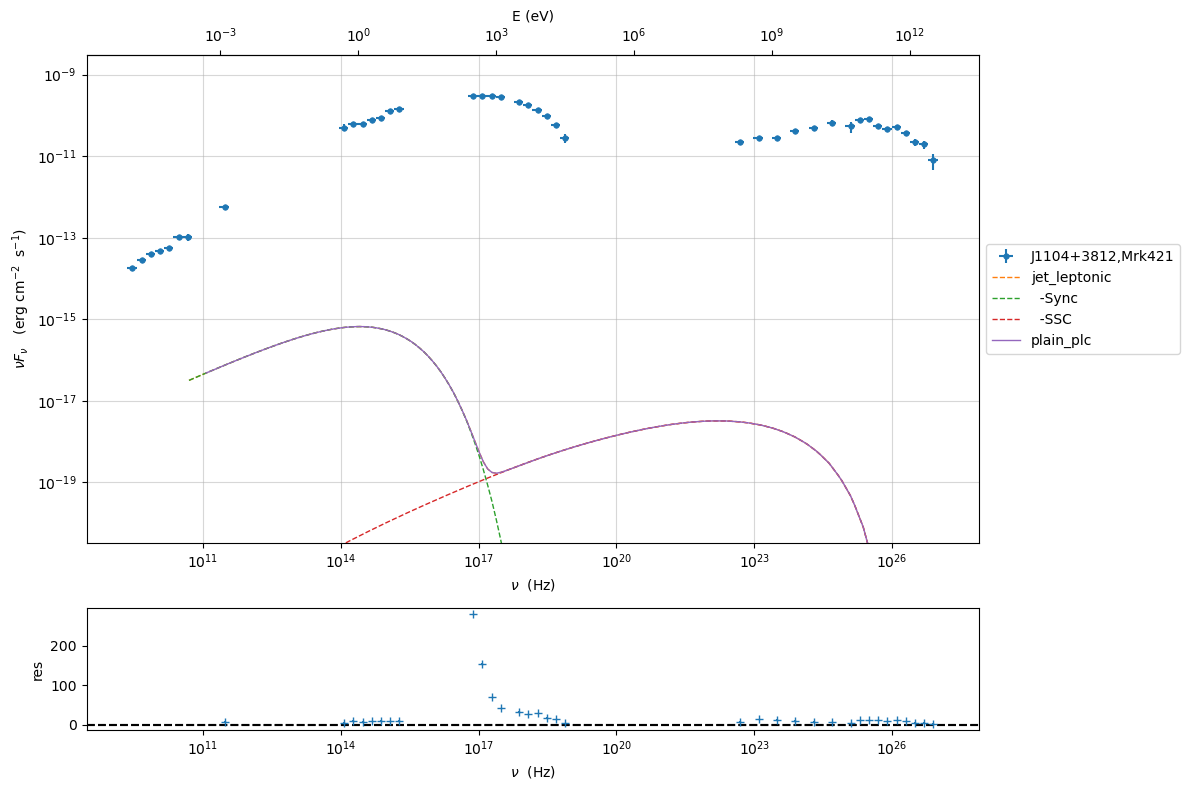

In [12]:
model_minimizer.fit_model.eval()
p=model_minimizer.fit_model.plot_model(sed_data=sed_data)

In [13]:

mcmc=UltraNestSampler(model_minimizer)

In [14]:
mcmc.model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,6.000000e+00,0.000000e+00,1.500000e+01,True,False
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False
jet_leptonic,p,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False


None

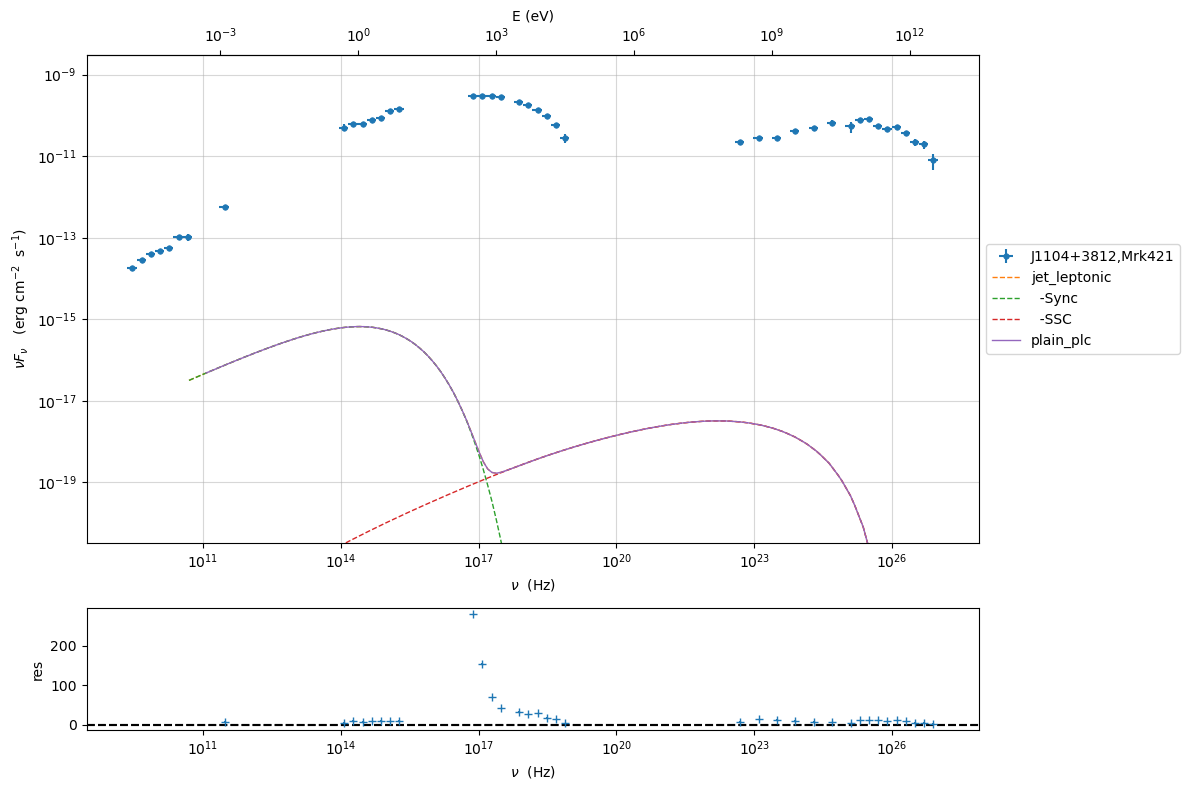

In [15]:
mcmc.model.eval()
mcmc.model.plot_model(sed_data=sed_data)

You can inspect the mcmc parameters using:

In [16]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,True,3.010300e-01,--,--,--,0.000000e+00,9.000000e+00,False
jet_leptonic,gmax,6.000000e+00,True,6.000000e+00,--,--,--,0.000000e+00,1.500000e+01,False
jet_leptonic,N,2.000000e+00,True,2.000000e+00,--,--,--,-2.000000e+02,--,False
jet_leptonic,gamma_cut,4.000000e+00,True,4.000000e+00,--,--,--,0.000000e+00,9.000000e+00,False
jet_leptonic,p,2.000000e+00,False,2.000000e+00,--,--,--,-1.000000e+01,1.000000e+01,False
jet_leptonic,R,1.569897e+01,True,1.569897e+01,--,--,--,3.000000e+00,3.000000e+01,False
jet_leptonic,B,-1.000000e+00,True,-1.000000e+00,--,--,--,-2.000000e+02,--,False
jet_leptonic,beam_obj,1.000000e+01,False,1.000000e+01,--,--,--,1.000000e-04,--,False
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


In [17]:
mcmc.model.parameters.best_fit_par_table

model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
str12,str16,float64,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,--,--,--,3.010300e-01,0.000000e+00,9.000000e+00,False
jet_leptonic,gmax,6.000000e+00,--,--,--,6.000000e+00,0.000000e+00,1.500000e+01,False
jet_leptonic,N,2.000000e+00,--,--,--,2.000000e+00,-2.000000e+02,--,False
jet_leptonic,gamma_cut,4.000000e+00,--,--,--,4.000000e+00,0.000000e+00,9.000000e+00,False
jet_leptonic,p,2.000000e+00,--,--,--,2.000000e+00,-1.000000e+01,1.000000e+01,False
jet_leptonic,R,1.569897e+01,--,--,--,1.569897e+01,3.000000e+00,3.000000e+01,False
jet_leptonic,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
jet_leptonic,B,-1.000000e+00,--,--,--,-1.000000e+00,-2.000000e+02,--,False
jet_leptonic,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True


If you want to exclude or include parameters from the samplers just freeze/free them 

In [18]:
mcmc.model.jet_leptonic.parameters.gmax.freeze()
mcmc.model.jet_leptonic.parameters.gmax.val=7

mcmc.set_bounds(par_name='p',comp_name='jet_leptonic',par_bounds=[1.5,3.5])
mcmc.set_bounds(par_name='N',comp_name='jet_leptonic',par_bounds=[-3,3])
mcmc.set_bounds(par_name='R',comp_name='jet_leptonic',par_bounds=[15,17])
mcmc.set_bounds(par_name='beam_obj',comp_name='jet_leptonic',par_bounds=[10,50])


mcmc.set_bounds(par_name='gmin',comp_name='jet_leptonic',par_bounds=[0,3.3])
mcmc.set_bounds(par_name='gamma_cut',comp_name='jet_leptonic',par_bounds=[3,6])
mcmc.set_bounds(par_name='B',comp_name='jet_leptonic',par_bounds=[-3,0])
 


par: p  ref value:  2.0  mcmc bounds: [1.5, 3.5]
par: N  ref value:  2.0  mcmc bounds: [np.float64(-3.0), np.float64(3.0)]
par: R  ref value:  15.698970004336019  mcmc bounds: [np.float64(15.0), np.float64(17.0)]
par: beam_obj  ref value:  10.0  mcmc bounds: [10, 50]
par: gmin  ref value:  0.3010299956639812  mcmc bounds: [np.float64(0.0), np.float64(3.3)]
par: gamma_cut  ref value:  4.0  mcmc bounds: [np.float64(3.0), np.float64(6.0)]
par: B  ref value:  -1.0  mcmc bounds: [np.float64(-3.0), np.float64(0.0)]


In [19]:
mcmc.model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,7.000000e+00,0.000000e+00,1.500000e+01,True,True
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False
jet_leptonic,p,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False


None

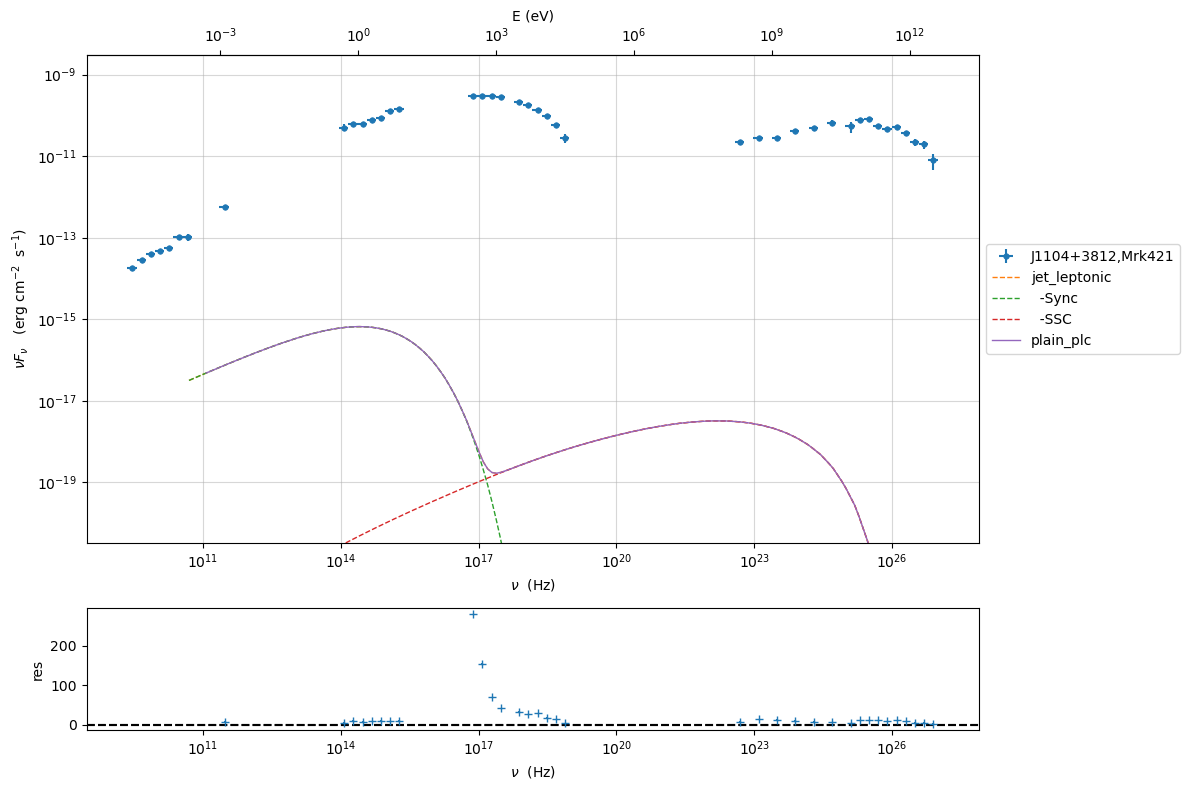

In [20]:
mcmc.model.eval()
mcmc.model.plot_model(sed_data=sed_data)

In [21]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,True,3.010300e-01,--,--,--,0.000000e+00,3.300000e+00,False
jet_leptonic,N,2.000000e+00,True,2.000000e+00,--,--,--,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,4.000000e+00,True,4.000000e+00,--,--,--,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.000000e+00,False,2.000000e+00,--,--,--,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.569897e+01,True,1.569897e+01,--,--,--,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.000000e+00,True,-1.000000e+00,--,--,--,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,1.000000e+01,False,1.000000e+01,--,--,--,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


## Running the sampler using Open MPI 

When using `run_open_mpi`, the root directory, storing the ultranest products and the mpi script will be `run_mpi`

The parameter `ultranest_output_dir`, created under `run_mpi`, by default, will be set to `f'ultranest_{self.model.name}'`. You can override it by passing the desired name.


Setting `n_proc=8`, will result in running 8 parallel processes, speeding up the sampler, increase the `n_proc` value up to the number of cores/cpus depending on your machine/cluster setup


In [22]:
from jetset.mcmc_ultranest import run_open_mpi

mcmc=run_open_mpi(mcmc,
                 n_proc=8, #it runs 8 parallel processes, speeding up the sampler, increase n_proc value up to the number of cores/cpus depending on yor machine/cluster setup
                 min_num_live_points=64,
                 nsteps=1,
                 max_num_improvement_loops=1, 
                 min_ess=100,
                 num_c_threads=0, #when using openmpi do not enable c-threads
                 ultranest_output_dir='ultranest_openmpi_runs', #to override the directory storing the ultranest products to be inspected if needed , placed in run_mpi/
)

====== ultranest script ========
from jetset.mcmc_ultranest import UltraNestSampler
mcmc=UltraNestSampler.load('sampler.pkl')

mcmc.model.set_num_c_threads(0)

mcmc.run_sampler(
                min_num_live_points=64,
                nsteps=1,
                max_num_improvement_loops=1,
                min_ess=100.0,
                ultranest_output_dir='ultranest_openmpi_runs',
            )
    
mcmc.save('sampler.pkl')

executing mpirun  -np 8 python run_jetset_ultranest.py


Creating directory for new run ultranest_openmpi_runs/run1
ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

[ultranest] Sampling 64 live points from prior ...


Mono-modal Volume: ~exp(-0.18) * Expected Volume: exp(0.00) Quality: ok

gmin     :  +3.3e-06| *** ************ ** ********    ***************| +3.3e+00
N        :      -3.0|******************   ******* * ** ** ***** **** |     +3.0
gamma_cut:      +3.0|* ** **** ***  ********  ***  *** ************ *|     +6.0
p        :      +1.5|***   ** * ***  ** ***** ** *******  ** *** ****|     +3.5
R        :     +15.0|**********  *** *  ***  **  ******** ** ****** *|    +17.0
B        :  -3.0e+00|*** * ****  ** * ****** **   **** *** ** *******| -3.0e-06
beam_obj :     +10.0|  * **** ***** ********* ******  ************** |    +50.0



Z=-75761.4(0.00%) | Like=-58269.22..-17031.87 [-8.13e+13..-5.694e+04] | it/evals=12/200 eff=8.8235% N=64 

Mono-modal Volume: ~exp(0.43) * Expected Volume: exp(-0.22) Quality: ok
Step sampler performance: 0.9 rej/step, 7 steps/it, rel jump distance: 0.38 (should be >1), 0.00% (should be >50%)

gmin     :  +3.3e-06| ************* ** ********* *    ****** **** ***| +3.3e+00
N        :      -3.0|******************   ** ****** *****  **** ** * |     +3.0
gamma_cut:      +3.0|  ** ********  ********  ** ***** ******** *****|     +6.0
p        :      +1.5|**    ** * ***  **** ***  * ******** ****** ****|     +3.5
R        :     +15.0| ********** *** *  * *****   ************ **** *|    +17.0
B        :  -3.0e+00|*** * **** **  * ****** *** **    *** ******* **| -3.0e-06
beam_obj :     +10.0|  * **********  ******** ******* ************   |    +50.0

Z=-56942.8(0.00%) | Like=-56940.77..-17031.87 [-8.13e+13..-5.694e+04] | it/evals=24/344 eff=8.2143% N=63 

Mono-modal Volume: ~exp(-1.35) * Expe

Z=-56942.0(0.00%) | Like=-56940.77..-17031.87 [-8.13e+13..-5.694e+04] | it/evals=42/544 eff=8.5417% N=63 

Mono-modal Volume: ~exp(-1.35)   Expected Volume: exp(-0.70) Quality: ok
Step sampler performance: 0.8 rej/step, 7 steps/it, rel jump distance: 0.56 (should be >1), 25.00% (should be >50%)

gmin     :  +3.3e-06| *  *******  * ** * *********  * ****** **** ***| +3.3e+00
N        :      -3.0|***  ***** ***** **  ** ****** *****  ********* |     +3.0
gamma_cut:      +3.0| * * * ****** ********   ** ********************|     +6.0
p        :      +1.5|** * ***  * *** **** *** ** ****** ****** *  ***|     +3.5
R        :     +15.0| *  ******* * *  * * ******  *******************|    +17.0
B        :      -3.0|*** *********  * ******** ** * **************** |     -0.0
beam_obj :     +10.0|    ***** ***** *** * ** * ***** ***************|    +50.0

[ultranest] Found 1 clusters, but only have 63 live points, want 80.
[ultranest] Explored until L=-6e+04  
[ultranest] Likelihood function eva

gmin     :  +3.3e-06| *  *******  **** * ******************* ********| +3.3e+00
N        :      -3.0|***  ***** ***** ** *** *********** * ********* |     +3.0
gamma_cut:      +3.0| * * * * **** *********  ** ********************|     +6.0
p        :      +1.5|** * *** ** ************ ** ****** ********  ***|     +3.5
R        :     +15.0| * ******** * *  *** **** *  *******************|    +17.0
B        :      -3.0|*** *********  * ******** **** **************** |     -0.0
beam_obj :     +10.0|  * ***** ***** ***** ** * ***** ***************|    +50.0

Z=-56941.6(0.00%) | Like=-56940.70..-17031.87 [-56940.7623..-56939.5152] | it/evals=72/976 eff=7.2917% N=79 

Mono-modal Volume: ~exp(-1.95) * Expected Volume: exp(-0.95) Quality: ok
Step sampler performance: 0.9 rej/step, 7 steps/it, rel jump distance: 0.61 (should be >1), 25.00% (should be >50%)

gmin     :  +3.3e-06|*   **** **  **************************  *******| +3.3e+00
N        :      -3.0|  * ****** ***** ** *** *********** **

...

Z=-46.3(98.22%) | Like=-17.58..-17.21 [-17.6496..-17.5439] | it/evals=2214/72536 eff=2.9954% N=64 

Mono-modal Volume: ~exp(-33.52)   Expected Volume: exp(-32.86) Quality: ok
Step sampler performance: 1.6 rej/step, 7 steps/it, rel jump distance: 0.45 (should be >1), 9.33% (should be >50%)

   negative degeneracy between N and gmin: rho=-0.93
   positive degeneracy between gamma_cut and gmin: rho=0.91
   negative degeneracy between gamma_cut and N: rho=-0.98
   positive degeneracy between R and gmin: rho=0.86
   negative degeneracy between R and N: rho=-0.98
   positive degeneracy between R and gamma_cut: rho=0.98
   negative degeneracy between B and gmin: rho=-0.86
   positive degeneracy between B and N: rho=0.88
   negative degeneracy between B and gamma_cut: rho=-0.89
   negative degeneracy between B and R: rho=-0.83
   positive degeneracy between beam_obj and N: rho=0.79
   negative degeneracy between beam_obj and gamma_cut: rho=-0.77
   negative degeneracy between beam_obj and R: r

Z=-46.3(98.49%) | Like=-17.54..-17.21 [-17.6496..-17.5439] | it/evals=2226/73008 eff=2.9924% N=64 

Mono-modal Volume: ~exp(-33.52)   Expected Volume: exp(-33.10) Quality: ok
Step sampler performance: 1.6 rej/step, 7 steps/it, rel jump distance: 0.45 (should be >1), 9.59% (should be >50%)

   negative degeneracy between N and gmin: rho=-0.92
   positive degeneracy between gamma_cut and gmin: rho=0.91
   negative degeneracy between gamma_cut and N: rho=-0.98
   positive degeneracy between R and gmin: rho=0.83
   negative degeneracy between R and N: rho=-0.97
   positive degeneracy between R and gamma_cut: rho=0.97
   negative degeneracy between B and gmin: rho=-0.86
   positive degeneracy between B and N: rho=0.87
   negative degeneracy between B and gamma_cut: rho=-0.89
   negative degeneracy between B and R: rho=-0.81
   positive degeneracy between beam_obj and N: rho=0.79
   negative degeneracy between beam_obj and gamma_cut: rho=-0.76
   negative degeneracy between beam_obj and R: r

Z=-46.3(98.83%) | Like=-17.51..-17.21 [-17.5430..-17.4446] | it/evals=2244/73688 eff=2.9892% N=64 

Mono-modal Volume: ~exp(-33.52)   Expected Volume: exp(-33.33) Quality: ok
Step sampler performance: 1.6 rej/step, 7 steps/it, rel jump distance: 0.46 (should be >1), 9.89% (should be >50%)

   negative degeneracy between N and gmin: rho=-0.90
   positive degeneracy between gamma_cut and gmin: rho=0.87
   negative degeneracy between gamma_cut and N: rho=-0.97
   positive degeneracy between R and gmin: rho=0.77
   negative degeneracy between R and N: rho=-0.96
   positive degeneracy between R and gamma_cut: rho=0.95
   negative degeneracy between B and gmin: rho=-0.82
   positive degeneracy between B and N: rho=0.80
   negative degeneracy between B and gamma_cut: rho=-0.83
   positive degeneracy between beam_obj and N: rho=0.78
   negative degeneracy between beam_obj and R: rho=-0.88
gmin     :      +0.0|                                 +2.7  **       |     +3.3
N        :      -1.0|     

Z=-46.3(99.00%) | Like=-17.48..-17.20 [-17.5430..-17.4446] | it/evals=2256/74304 eff=2.9805% N=64 

Mono-modal Volume: ~exp(-34.44) * Expected Volume: exp(-33.57) Quality: ok
Step sampler performance: 1.6 rej/step, 7 steps/it, rel jump distance: 0.46 (should be >1), 9.85% (should be >50%)

   negative degeneracy between N and gmin: rho=-0.87
   positive degeneracy between gamma_cut and gmin: rho=0.85
   negative degeneracy between gamma_cut and N: rho=-0.98
   negative degeneracy between R and N: rho=-0.96
   positive degeneracy between R and gamma_cut: rho=0.96
   negative degeneracy between B and gmin: rho=-0.82
   positive degeneracy between B and N: rho=0.82
   negative degeneracy between B and gamma_cut: rho=-0.84
   positive degeneracy between beam_obj and N: rho=0.79
   negative degeneracy between beam_obj and gamma_cut: rho=-0.76
   negative degeneracy between beam_obj and R: rho=-0.89
gmin     :      +0.0|                                 +2.7  **       |     +3.3
N        :   

[ultranest] Explored until L=-2e+01  
[ultranest] Likelihood function evaluations: 74728
ultranest run done, took 47.90 seconds
ultranest run done, took 47.90 seconds
ultranest run done, took 47.91 seconds
ultranest run done, took 47.91 seconds
----------------------------
UltraNest best fit solution
----------------------------
UltraNest best fit solution
----------------------------
UltraNest best fit solution
ultranest run done, took 47.91 seconds
[ultranest] Writing samples and results to disk ...
comp: jet_leptonic par: gmin ultranest best fit val: 2.766914137382549 quantiles(0.16,0.5,0.84): [2.69479342 2.75756283 2.81428066]
comp: jet_leptonic par: gmin ultranest best fit val: 2.766914137382549 quantiles(0.16,0.5,0.84): [2.69479342 2.75756283 2.81428066]
comp: jet_leptonic par: N ultranest best fit val: -0.18036525136393378 quantiles(0.16,0.5,0.84): [-0.32896637 -0.13907016  0.07027006]
comp: jet_leptonic par: N ultranest best fit val: -0.18036525136393378 quantiles(0.16,0.5,0.84

[<Figure size 1000x2100 with 7 Axes>]

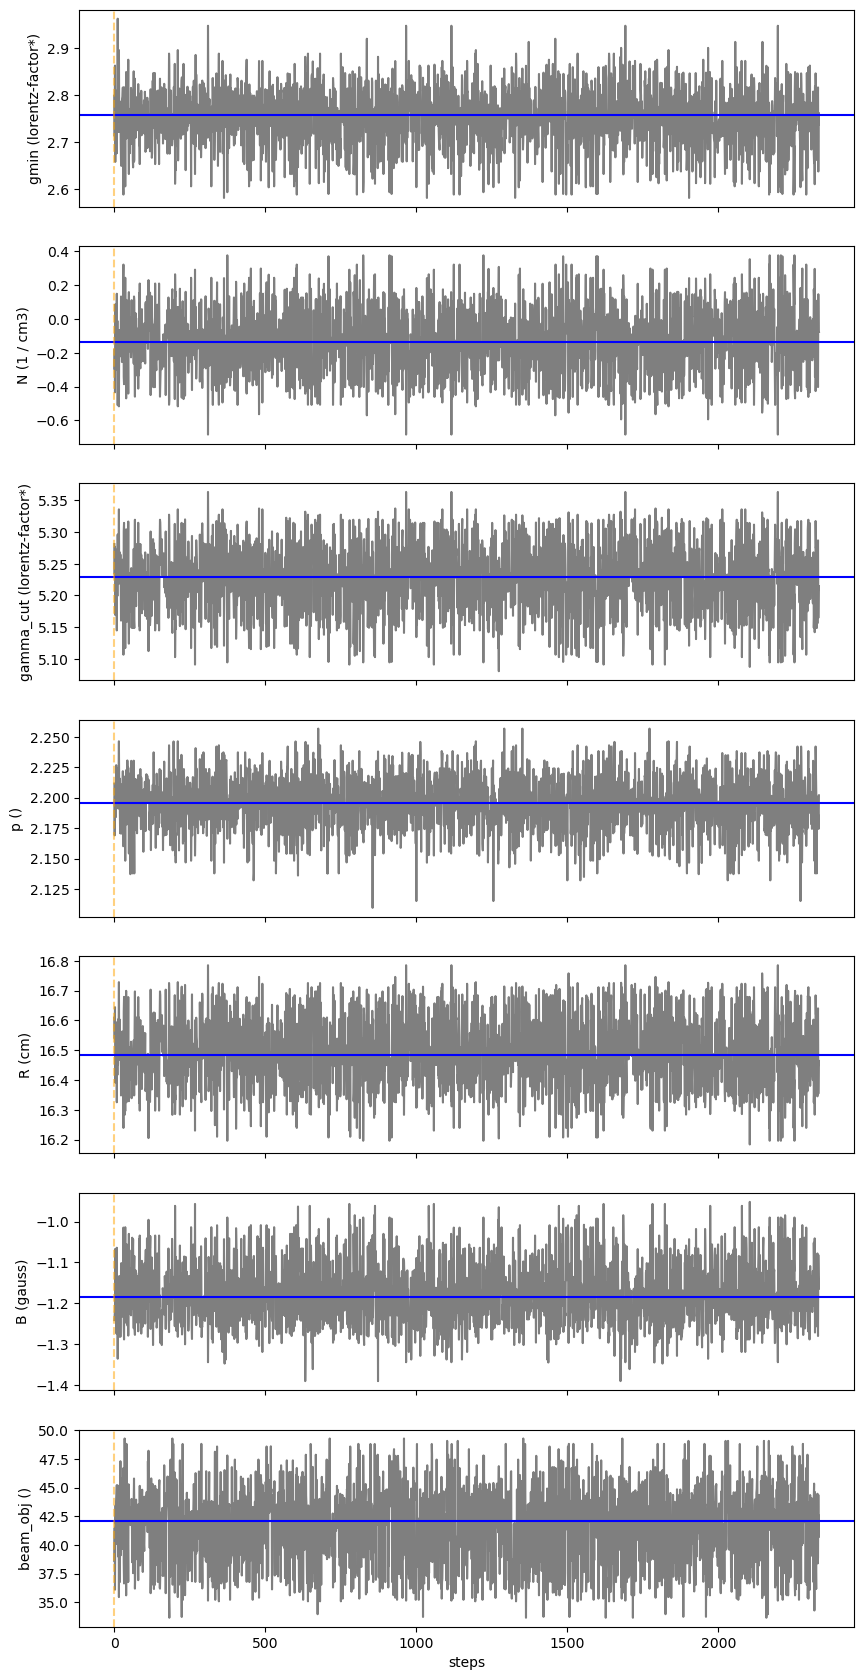

In [23]:
mcmc.plot_chain()

In [24]:
#mcmc.tune_burnin(tau_cor_coeff=4)

Showing the MCMC parameters. Now MCMC bestfit values are updated to the best-fit MCMC solution


In [25]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,2.766914e+00,True,2.766914e+00,2.694793e+00,2.757563e+00,2.814281e+00,0.000000e+00,3.300000e+00,False
jet_leptonic,N,-1.803653e-01,True,-1.803653e-01,-3.289664e-01,-1.390702e-01,7.027006e-02,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,5.236050e+00,True,5.236050e+00,5.169419e+00,5.229566e+00,5.281317e+00,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.194355e+00,False,2.194355e+00,2.173925e+00,2.195706e+00,2.217634e+00,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.652393e+01,True,1.652393e+01,1.636828e+01,1.648541e+01,1.660985e+01,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.176608e+00,True,-1.176608e+00,-1.251724e+00,-1.185788e+00,-1.096114e+00,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,3.977443e+01,False,3.977443e+01,3.744985e+01,4.206798e+01,4.481877e+01,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


### plotting the posterior corner plot

To have a better rendering on the scatter plot, we redefine the plot labels

In [26]:
mcmc.set_plot_label('N',r'log($N$)',comp_name='jet_leptonic')
mcmc.set_plot_label('R',r'log($R$)',comp_name='jet_leptonic')
mcmc.set_plot_label('B',r'log($B$)',comp_name='jet_leptonic')

mcmc.set_plot_label('gmin',r'log($\gamma_{\rm min}$)',comp_name='jet_leptonic')
mcmc.set_plot_label('p',r'$p$',comp_name='jet_leptonic')
#mcmc.set_plot_label('r',r'$r$',comp_name='jet_leptonic')
mcmc.set_plot_label('gamma_cut',r'$\gamma_{\rm cut}$',comp_name='jet_leptonic')
mcmc.set_plot_label('beam_obj',r'$\delta$',comp_name='jet_leptonic')



the code below lets you tuning the output

1) mpl.rcParams['figure.dpi'] if you increase it you get a better definition
2) title_fmt=".2E" this is the format for python, 2 significant digits, scientific notation
3) title_kwargs=dict(fontsize=12) you can change the fontsize

Per-component corner plot

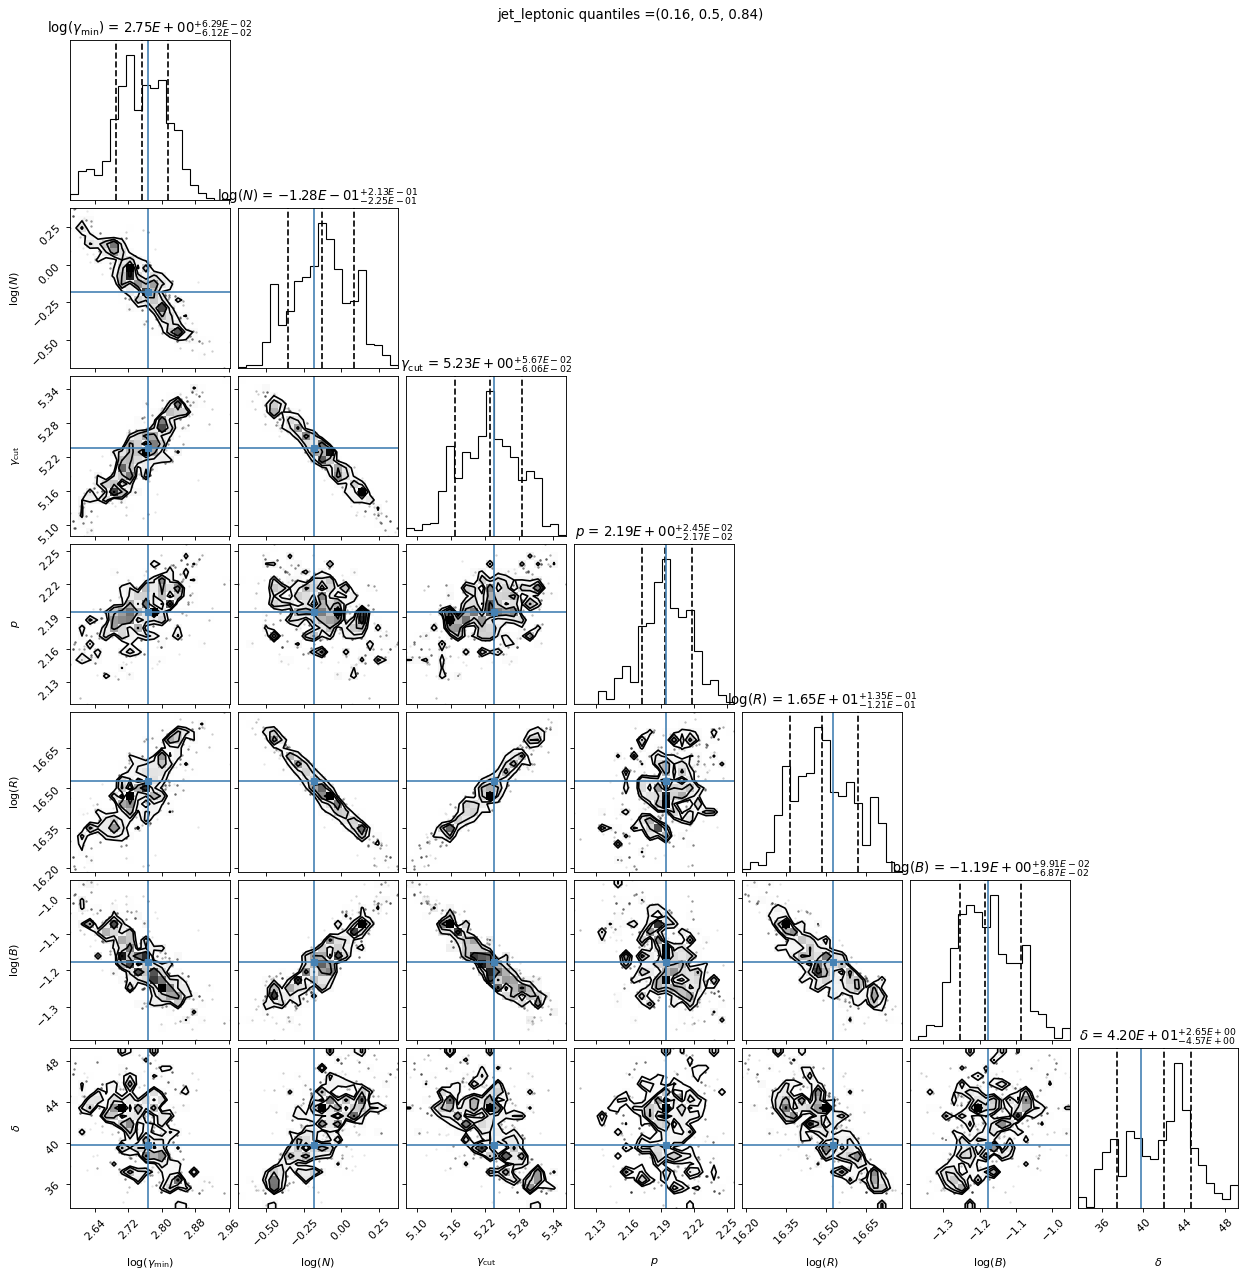

In [27]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


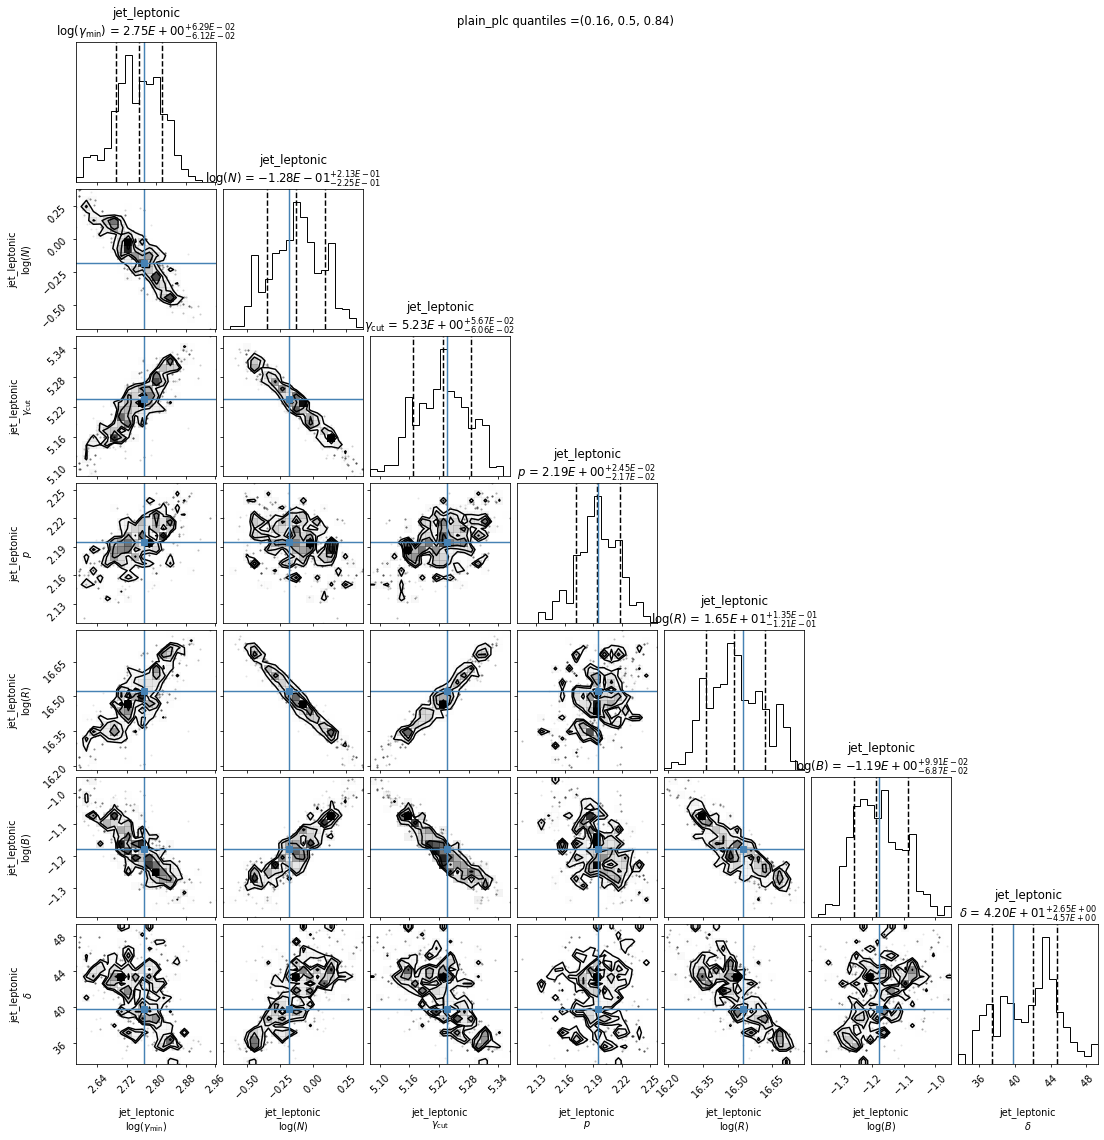

In [28]:
mpl.rcParams['figure.dpi'] = 70
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)

### plotting the model

To plot the sampled model range against the input mcmc best-fit model

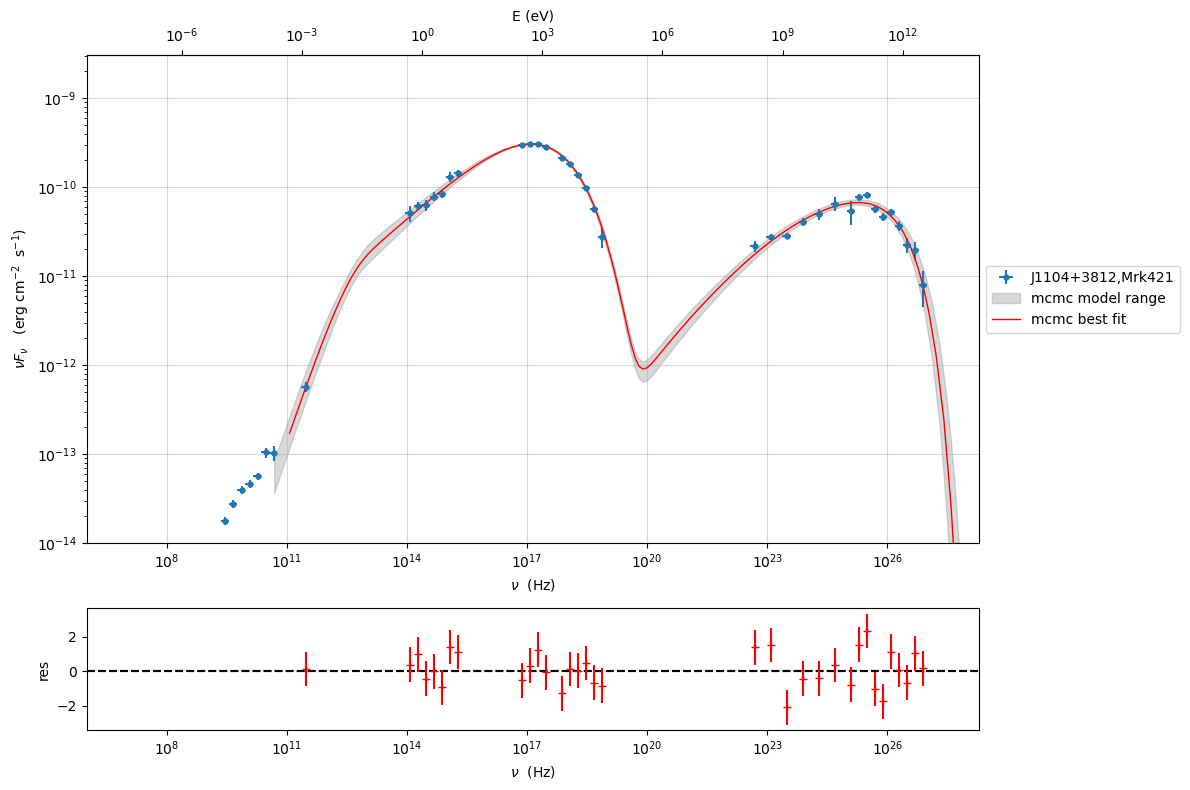

In [29]:

from jetset.data_loader import ObsData
sed_data=ObsData.load('Mrk_401.pkl')
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=600)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the mcmc best-fit model providing quantiles. The size parameter defines the number of samples to use to extract the quantiles. I am using a size equal to the number of steps

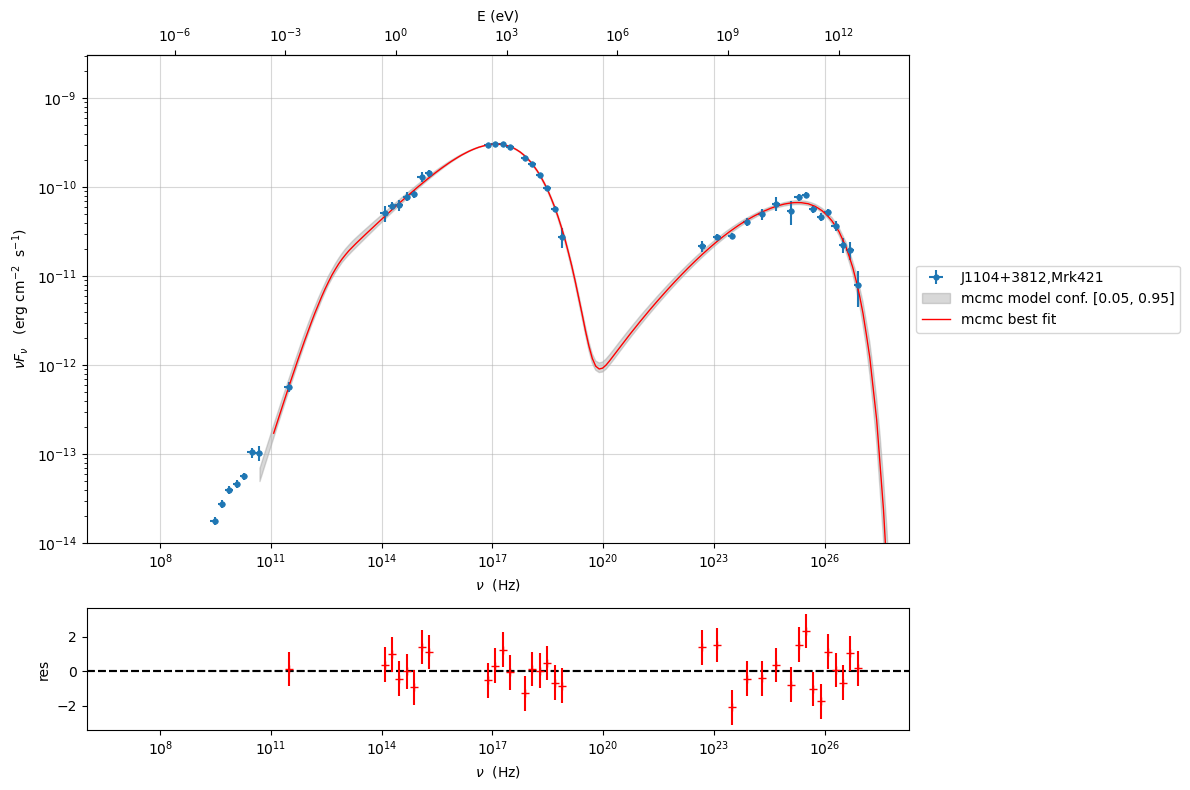

In [30]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95])
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

If you want to plot also the model components, pass the argument `plot_components=True`

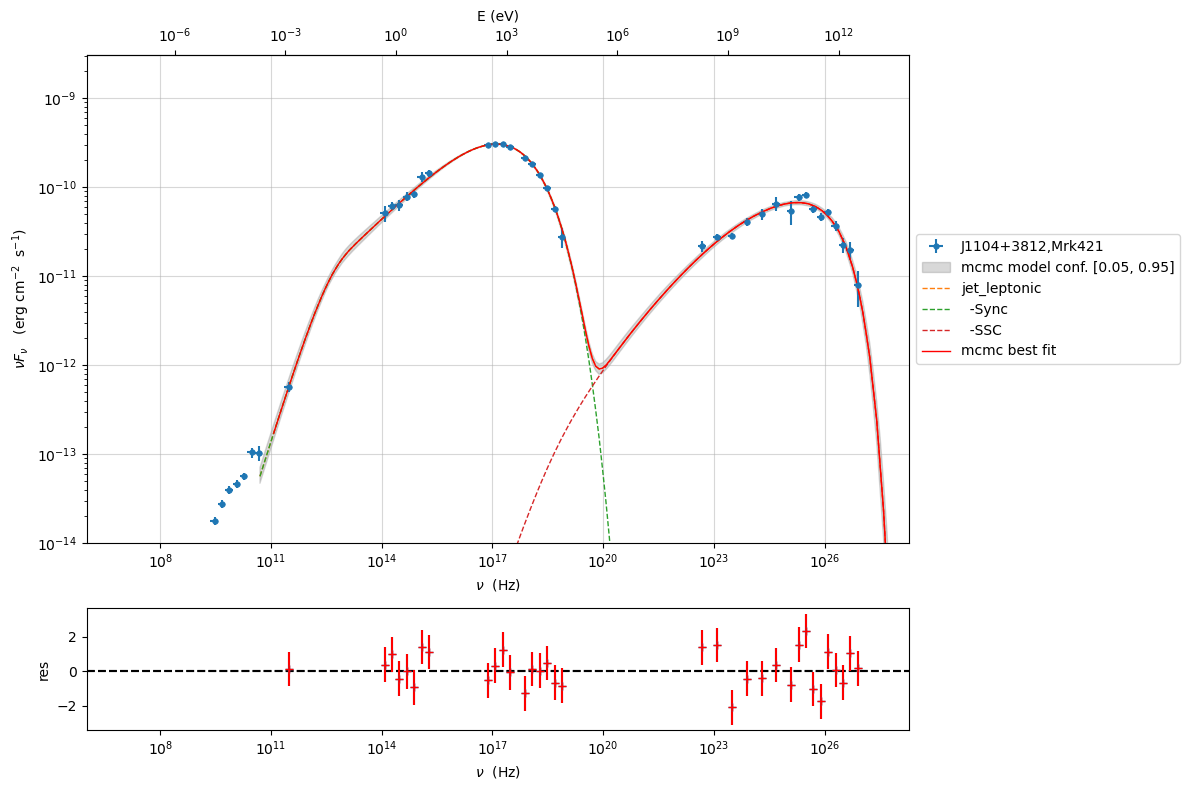

In [31]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)


To plot the frequentist  best-fit  model range,p roviding quantiles, provide (``plot_mcmc_best_fit_model=False``)

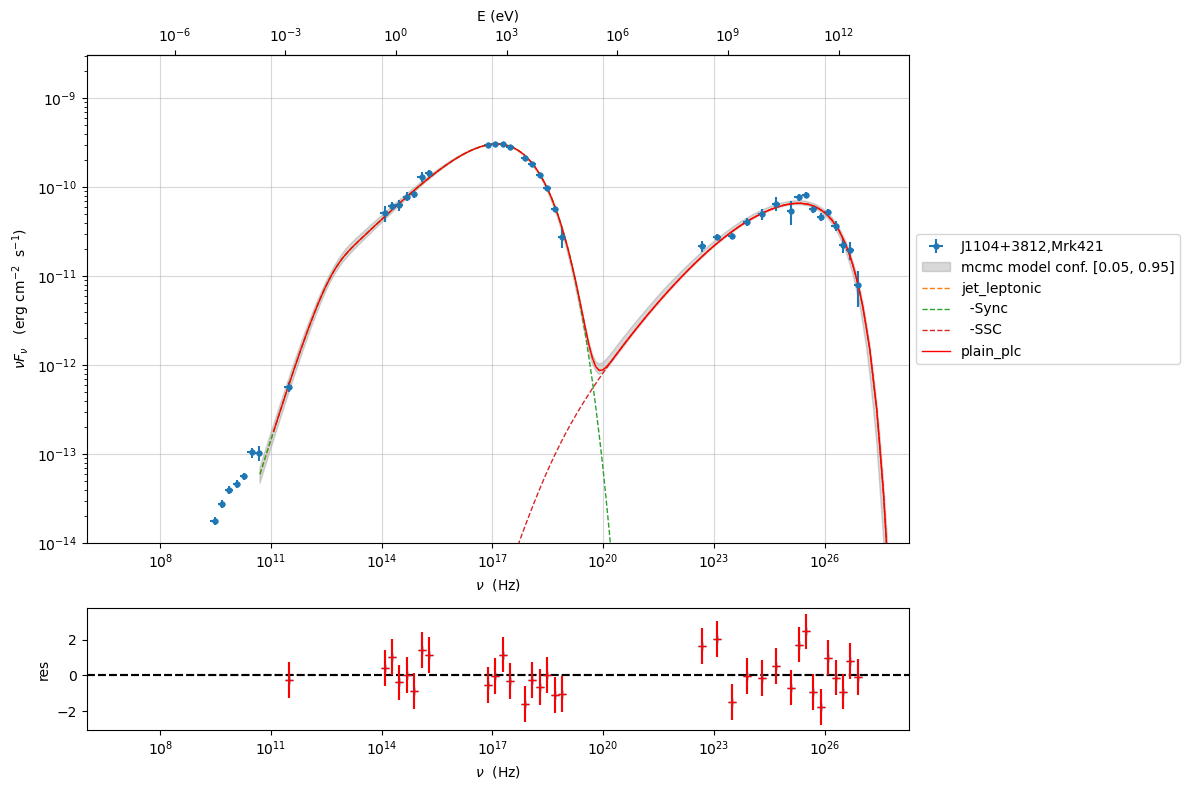

In [32]:
mpl.rcParams['figure.dpi'] = 100
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95], plot_mcmc_best_fit_model=False,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### plotting chains and individual posteriors

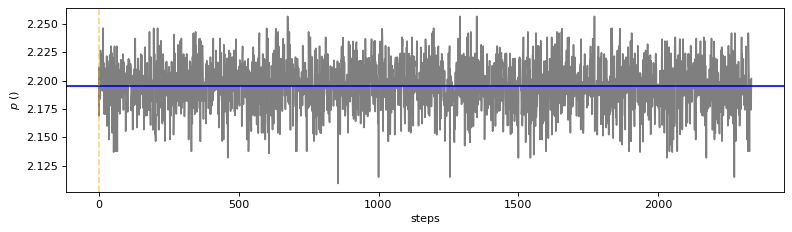

In [33]:
import matplotlib.pylab as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(par_name='p',log_plot=False)
plt.tight_layout()

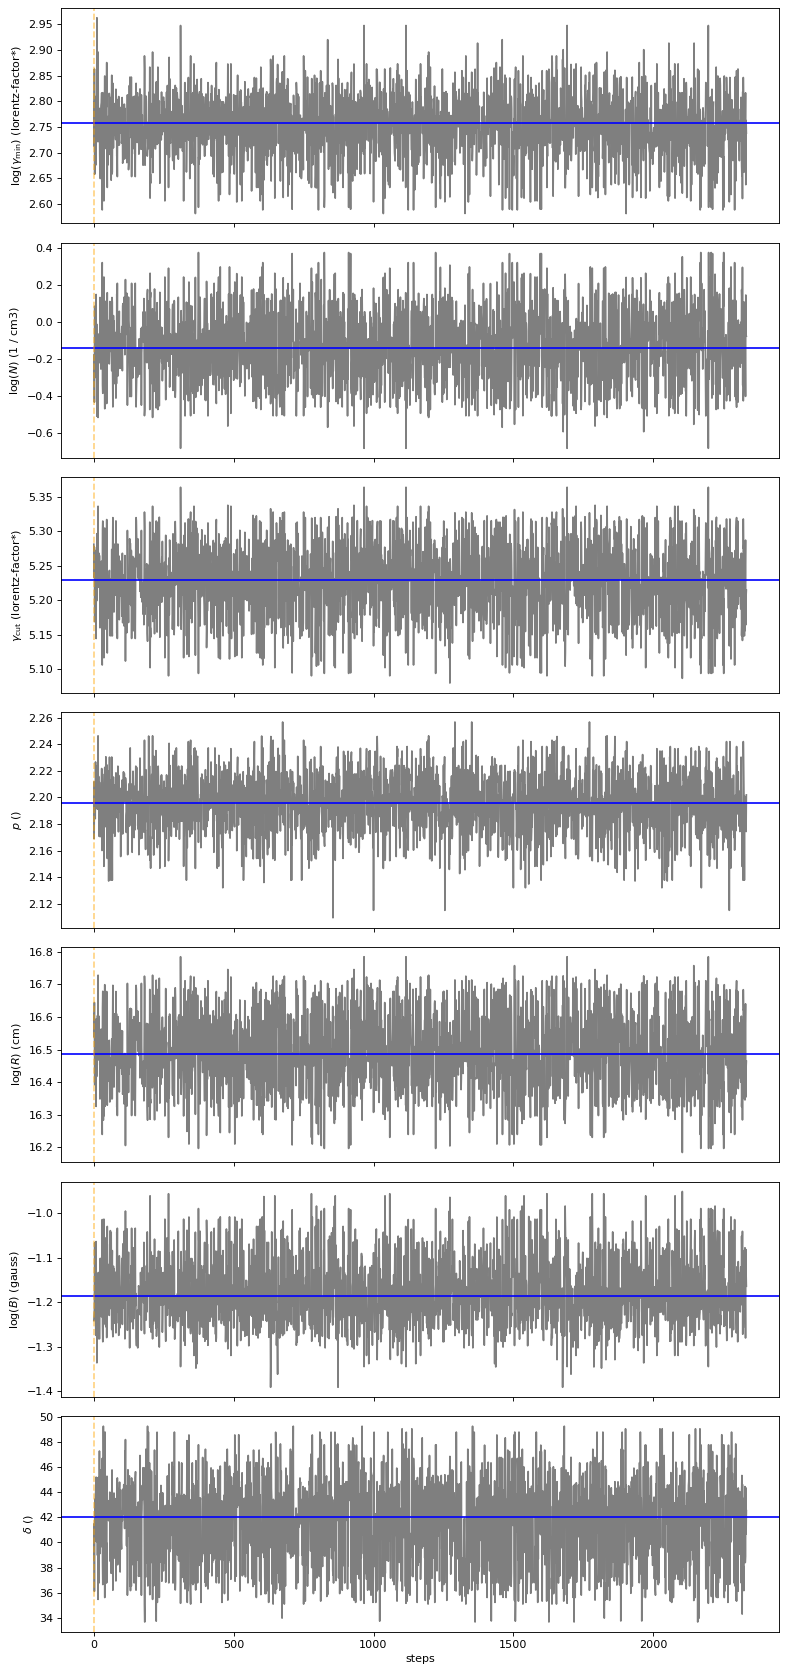

In [34]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(log_plot=False)
plt.tight_layout()

## Saving and reloading the sampler

In [35]:
mcmc.save('mcmc_sampler_ultranest_plain_openmpi.pkl')

In [36]:
from jetset.mcmc import McmcSampler
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_401.pkl')
ms=McmcSampler.load('mcmc_sampler_ultranest_plain_openmpi.pkl')

import matplotlib as mpl


In [37]:
ms.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,2.766914e+00,True,2.766914e+00,2.694793e+00,2.757563e+00,2.814281e+00,0.000000e+00,3.300000e+00,False
jet_leptonic,N,-1.803653e-01,True,-1.803653e-01,-3.289664e-01,-1.390702e-01,7.027006e-02,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,5.236050e+00,True,5.236050e+00,5.169419e+00,5.229566e+00,5.281317e+00,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.194355e+00,False,2.194355e+00,2.173925e+00,2.195706e+00,2.217634e+00,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.652393e+01,True,1.652393e+01,1.636828e+01,1.648541e+01,1.660985e+01,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.176608e+00,True,-1.176608e+00,-1.251724e+00,-1.185788e+00,-1.096114e+00,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,3.977443e+01,False,3.977443e+01,3.744985e+01,4.206798e+01,4.481877e+01,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


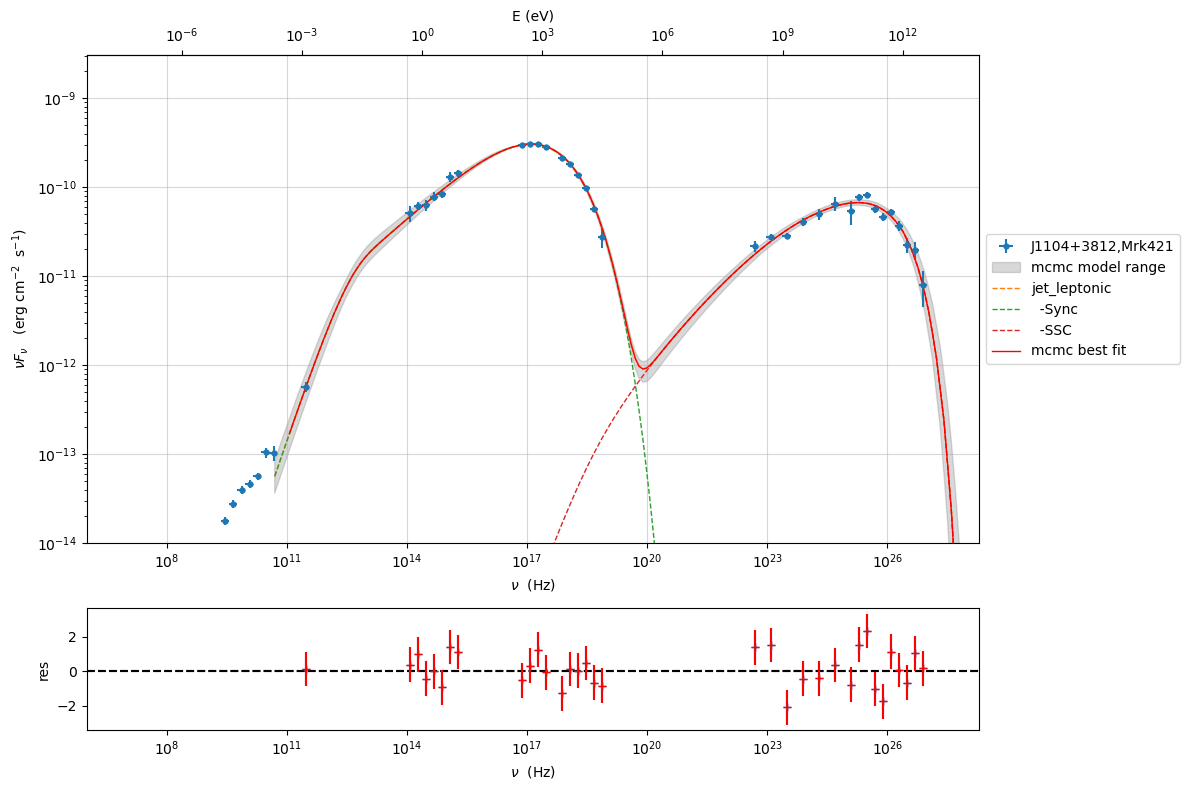

In [38]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=500,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

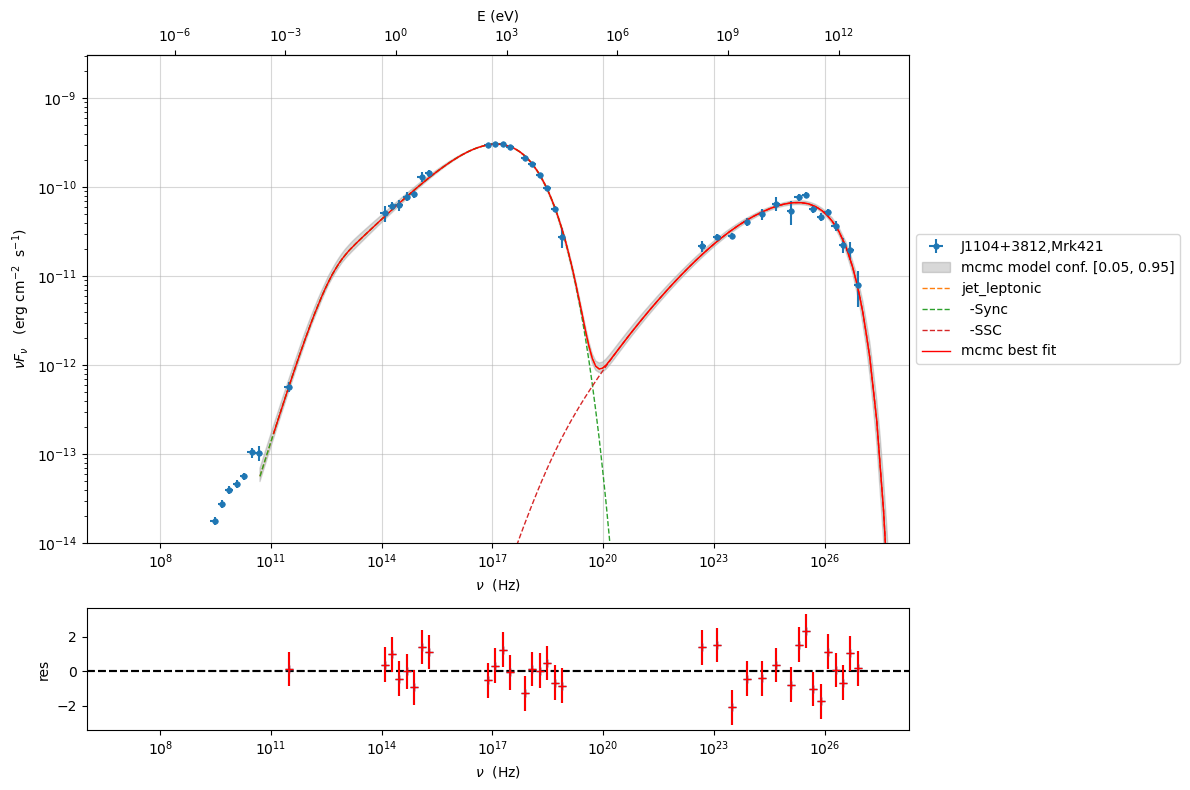

In [39]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

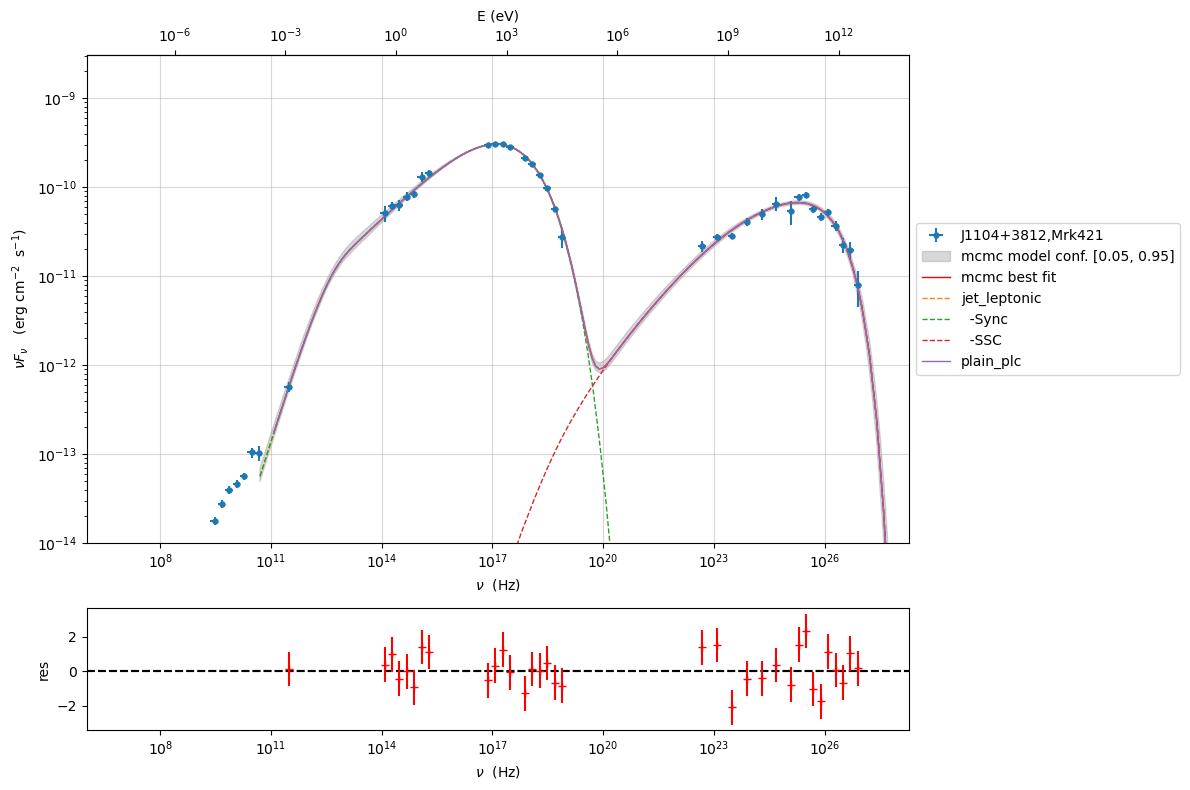

In [40]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_mcmc_best_fit_model=True)
p=ms.model.plot_model(plot_obj=p)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

Per-component corner plot

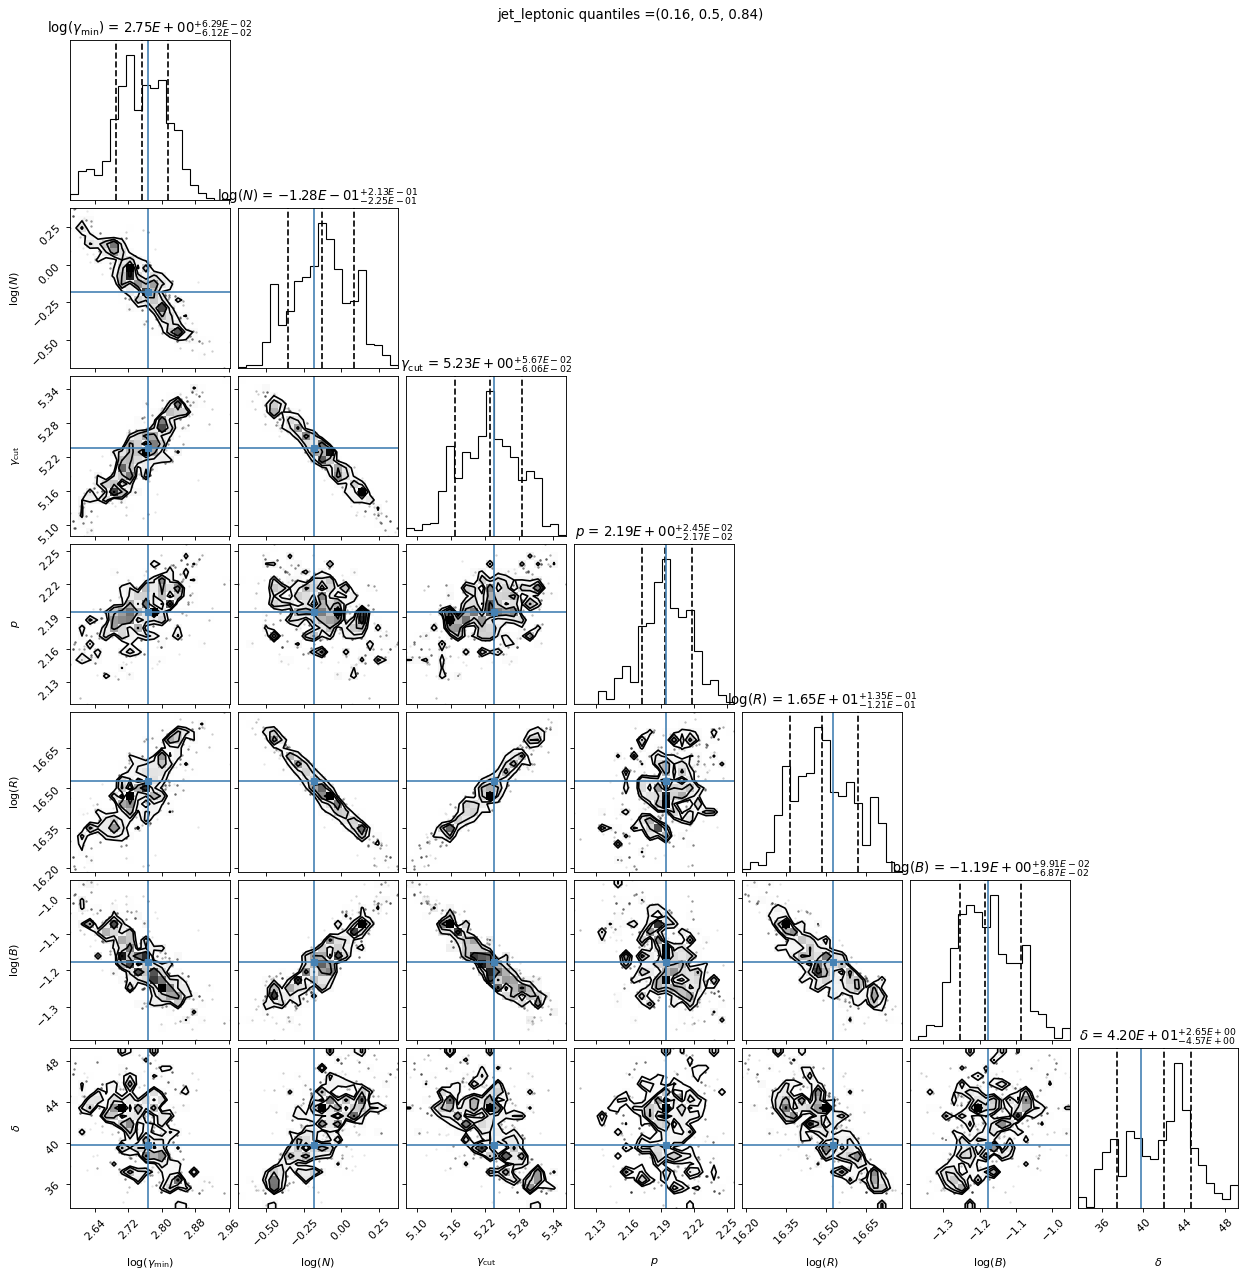

In [41]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


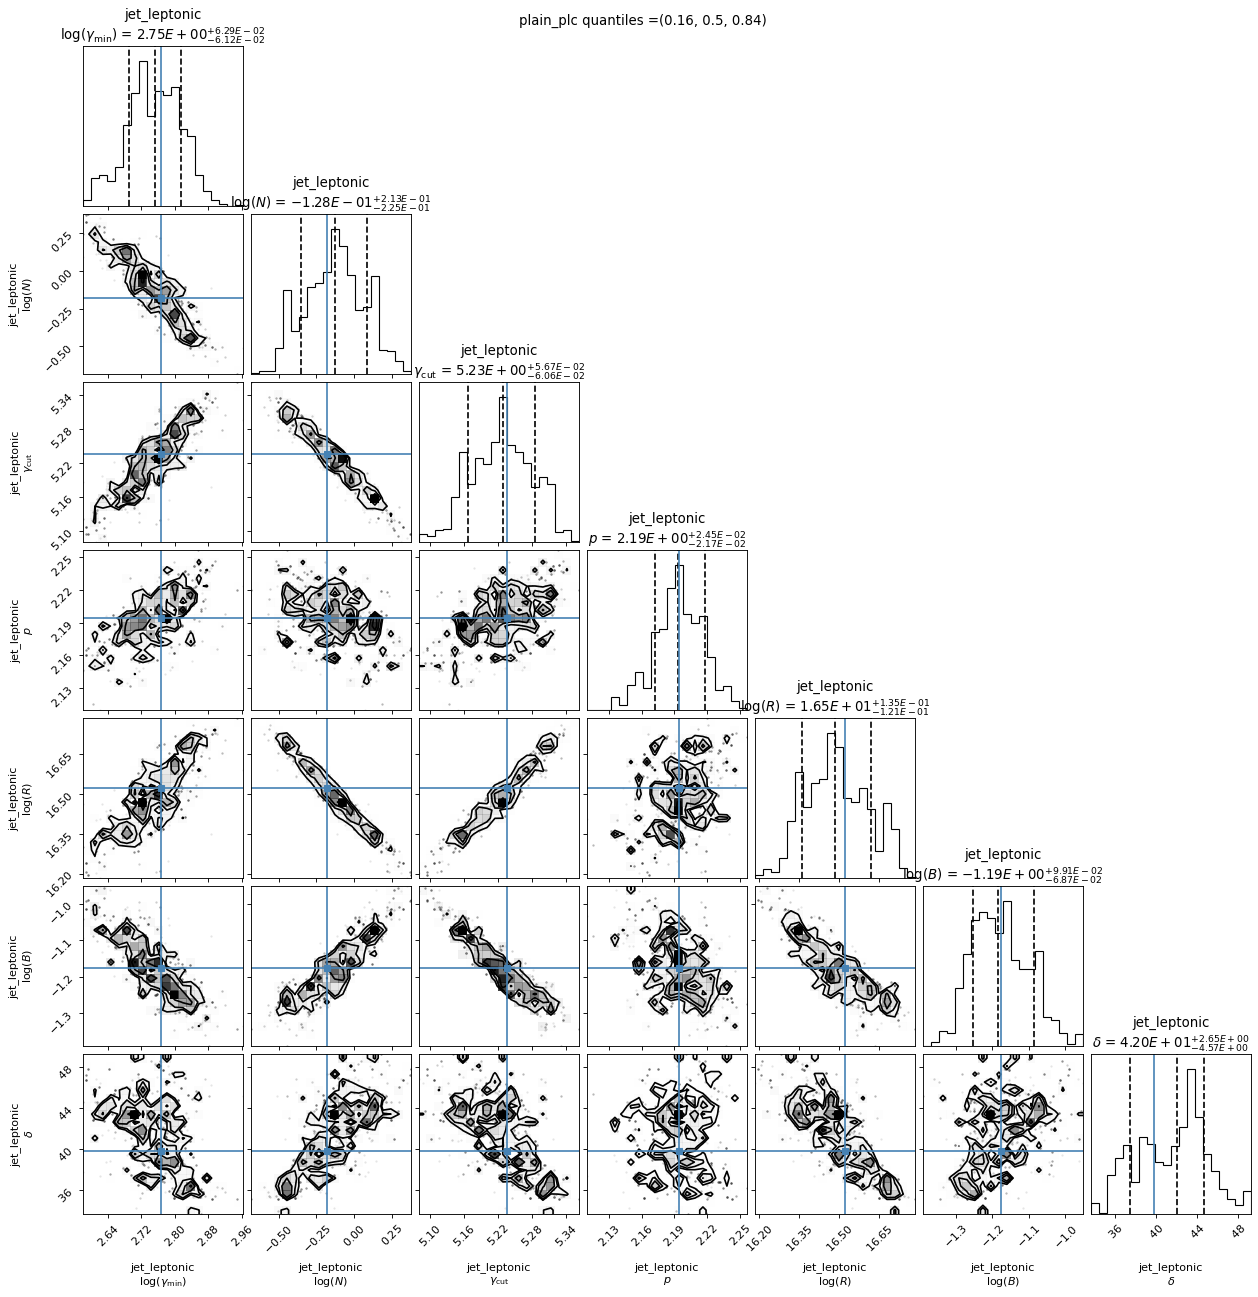

In [42]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)